In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import LabelEncoder

In [ ]:
# =====================================================================
# Data Collection & Loading (Categorical → Numerical)
# =====================================================================
#  Import dataset from: CSV / Excel / Database / API
#  Load using appropriate tools (e.g., pandas)
#  Validate:Dataset size & Column structure

df = pd.read_csv("/content/synthetic_disaster_events_2025.csv")

In [ ]:
df.shape, df.columns

((20000, 13),
 Index(['event_id', 'disaster_type', 'location', 'latitude', 'longitude',
        'date', 'severity_level', 'affected_population',
        'estimated_economic_loss_usd', 'response_time_hours', 'aid_provided',
        'infrastructure_damage_index', 'is_major_disaster'],
       dtype='object'))

In [ ]:
# =====================================================================
# Data Collection & Loading (Categorical → Numerical)
# =====================================================================
#  head, tail, info & Describe
#  Datatype, Missing values, & Unique Values. Data Consistency
df.head()

,event_id,disaster_type,location,latitude,longitude,date,severity_level,affected_population,estimated_economic_loss_usd,response_time_hours,aid_provided,infrastructure_damage_index,is_major_disaster
0,1,Wildfire,Chile,-34.681672,-71.819529,2025-08-27,8,31104,2768213.39,5.12,Yes,0.59,1
1,2,Hurricane,India,22.128569,78.023951,2023-05-29,5,29340,5996226.87,44.43,No,0.26,0
2,3,Volcanic Eruption,Italy,42.316058,11.031447,2023-01-15,7,34804,9222541.48,49.30,No,0.94,1
3,4,Drought,Chile,-33.436253,-69.984615,2024-02-08,8,31191,1827703.09,65.56,Yes,0.94,1
4,5,Volcanic Eruption,Turkey,39.400977,37.006822,2023-12-23,8,46284,13435921.49,60.96,No,0.92,1


In [ ]:
df.tail()

,event_id,disaster_type,location,latitude,longitude,date,severity_level,affected_population,estimated_economic_loss_usd,response_time_hours,aid_provided,infrastructure_damage_index,is_major_disaster
19995,19996,Volcanic Eruption,India,19.962542,82.590546,2025-11-16,6,28135,2556182.54,38.71,No,0.69,0
19996,19997,Volcanic Eruption,Japan,35.853659,138.522874,2025-04-08,2,4340,1228534.00,7.67,No,0.18,0
19997,19998,Hurricane,Philippines,13.720136,121.306074,2025-08-26,8,44663,8518260.66,9.76,Yes,0.75,1
19998,19999,Volcanic Eruption,India,19.959071,77.272460,2023-03-24,7,37484,10802942.53,13.87,Yes,0.77,1
19999,20000,Landslide,Chile,-36.842195,-68.613505,2023-04-05,6,34441,8966848.02,4.01,Yes,0.60,0


In [ ]:
df.columns

Index(['event_id', 'disaster_type', 'location', 'latitude', 'longitude',
       'date', 'severity_level', 'affected_population',
       'estimated_economic_loss_usd', 'response_time_hours', 'aid_provided',
       'infrastructure_damage_index', 'is_major_disaster'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   event_id                     20000 non-null  int64  
 1   disaster_type                20000 non-null  object 
 2   location                     20000 non-null  object 
 3   latitude                     20000 non-null  float64
 4   longitude                    20000 non-null  float64
 5   date                         20000 non-null  object 
 6   severity_level               20000 non-null  int64  
 7   affected_population          20000 non-null  int64  
 8   estimated_economic_loss_usd  20000 non-null  float64
 9   response_time_hours          20000 non-null  float64
 10  aid_provided                 20000 non-null  object 
 11  infrastructure_damage_index  20000 non-null  float64
 12  is_major_disaster            20000 non-null  int64  
dtypes: float64(5), i

In [ ]:
df.isnull().sum()

,0
event_id,0
disaster_type,0
location,0
latitude,0
longitude,0
date,0
severity_level,0
affected_population,0
estimated_economic_loss_usd,0
response_time_hours,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.describe(include = "all")

,event_id,disaster_type,location,latitude,longitude,date,severity_level,affected_population,estimated_economic_loss_usd,response_time_hours,aid_provided,infrastructure_damage_index,is_major_disaster
count,20000.000000,20000,20000,20000.000000,20000.000000,20000,20000.000000,20000.000000,2.000000e+04,20000.000000,20000,20000.000000,20000.00000
unique,NaN,7,8,NaN,NaN,1096,NaN,NaN,NaN,NaN,2,NaN,NaN
top,NaN,Earthquake,India,NaN,NaN,2024-12-12,NaN,NaN,NaN,NaN,Yes,NaN,NaN
freq,NaN,2910,2583,NaN,NaN,34,NaN,NaN,NaN,NaN,14030,NaN,NaN
mean,10000.500000,NaN,NaN,18.749811,41.976629,NaN,5.489300,27641.248950,4.831073e+06,36.369664,NaN,0.557306,0.40005
std,5773.647028,NaN,NaN,25.026759,82.535922,NaN,2.866269,16017.199074,3.624308e+06,20.420570,NaN,0.209064,0.48992
min,1.000000,NaN,NaN,-43.127383,-102.133704,NaN,1.000000,0.000000,0.000000e+00,1.000000,NaN,0.060000,0.00000
25%,5000.750000,NaN,NaN,3.560059,8.346726,NaN,3.000000,14755.000000,2.024090e+06,18.407500,NaN,0.400000,0.00000
50%,10000.500000,NaN,NaN,24.361006,74.600322,NaN,5.000000,27612.500000,4.031418e+06,36.560000,NaN,0.550000,0.00000
75%,15000.250000,NaN,NaN,38.285895,117.460836,NaN,8.000000,40016.500000,7.018268e+06,54.020000,NaN,0.700000,1.00000


In [ ]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns
print("Numerical Columns:")
print(list(numerical_cols))
print("\nCategorical Columns:")
print(list(categorical_cols))

Numerical Columns:
['event_id', 'latitude', 'longitude', 'severity_level', 'affected_population', 'estimated_economic_loss_usd', 'response_time_hours', 'infrastructure_damage_index', 'is_major_disaster']

Categorical Columns:
['disaster_type', 'location', 'date', 'aid_provided']


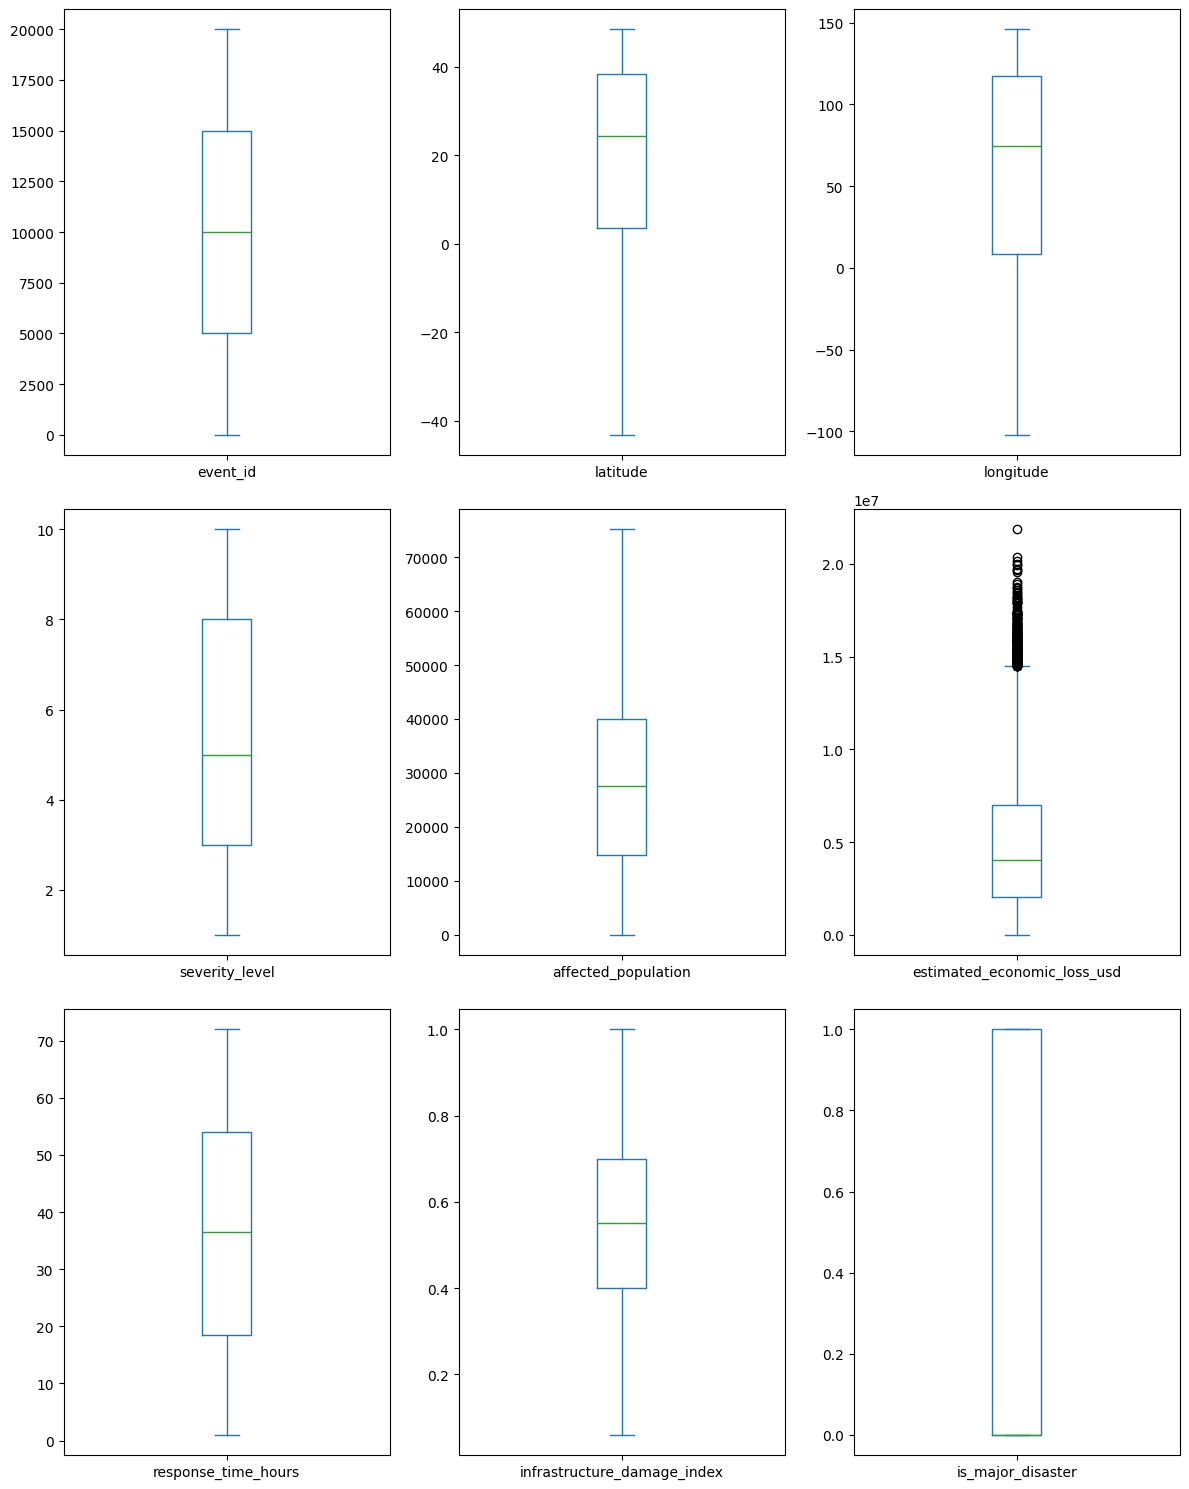

In [ ]:
# =====================================================================
# Data Collection & Loading (Categorical → Numerical)
# =====================================================================
#  Capture Outliers of Economic Loss
#  The Skewness is the near to the Zero. Its normalized one.
#  Handling the past data with the .clip(lower, upper) syntax. And Proceeding accordingly
df.plot(
    kind='box',
    subplots=True,
    layout=(-1,3),
    figsize=(12,15)
)

plt.tight_layout()
plt.show()

In [ ]:
df["estimated_economic_loss_usd"].skew()

np.float64(0.8746369133142001)

In [ ]:
Q1 = df['estimated_economic_loss_usd'].quantile(0.25)
Q3 = df['estimated_economic_loss_usd'].quantile(0.75)
iqr = Q3 - Q1
lower = Q1 - 1.5 * iqr
lower
upper = Q3 + 1.5 * iqr
lower, upper

(np.float64(-5467177.2475), np.float64(14509535.452499999))

✔ Step 5 Complete. Validation plot exported to 'outlier_detection_treatment.png'.


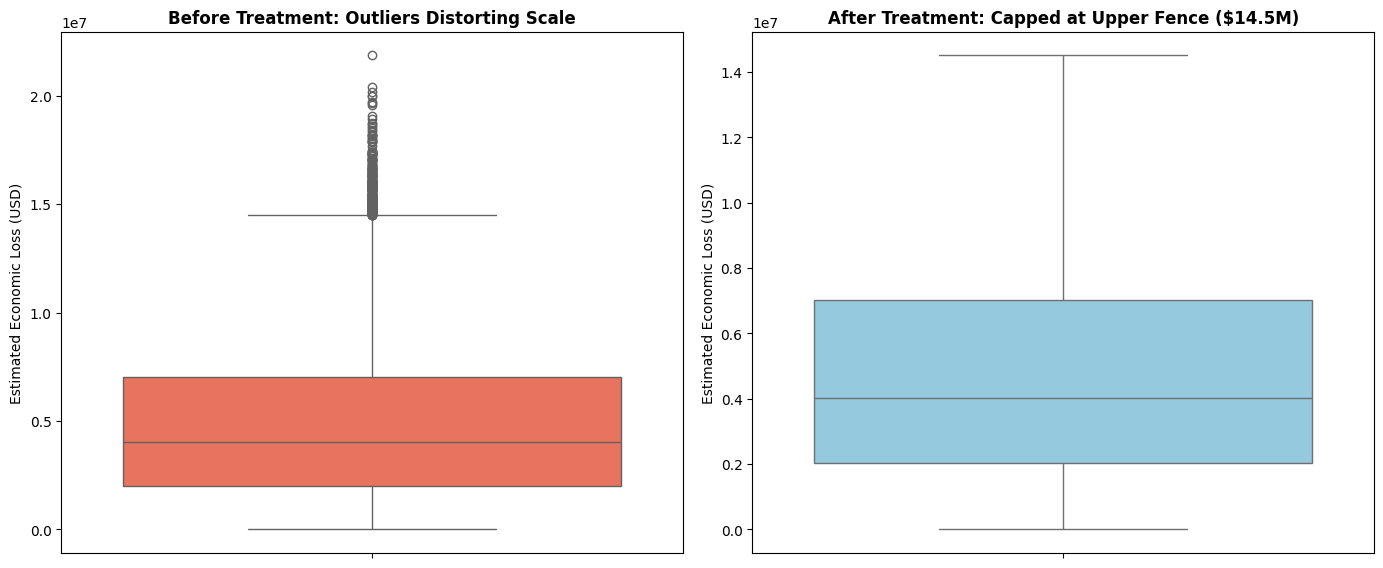

In [ ]:
df_cleaned = df.copy()
df_cleaned['estimated_economic_loss_usd'] = df_cleaned['estimated_economic_loss_usd'].clip(lower=lower, upper=upper)

# 5. Export Verification Visualizations
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.set_theme(style="whitegrid")

# Left Plot: Raw data with extreme tail extensions
sns.boxplot(data=df, y='estimated_economic_loss_usd', ax=axes[0], color='tomato')
axes[0].set_title('Before Treatment: Outliers Distorting Scale', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Estimated Economic Loss (USD)')

# Right Plot: Capped data with a clean, stabilized distribution
sns.boxplot(data=df_cleaned, y='estimated_economic_loss_usd', ax=axes[1], color='skyblue')
axes[1].set_title('After Treatment: Capped at Upper Fence ($14.5M)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Estimated Economic Loss (USD)')

plt.tight_layout()
plt.savefig('outlier_detection_treatment.png', dpi=300)
print("✔ Step 5 Complete. Validation plot exported to 'outlier_detection_treatment.png'.")

In [ ]:
features = [
    'disaster_type', 'severity_level', 'affected_population',
    'estimated_economic_loss_usd', 'response_time_hours',
    'aid_provided', 'infrastructure_damage_index'
]

In [ ]:
X = df[features]
y = df['is_major_disaster']

In [ ]:
X = pd.get_dummies(X, drop_first=True)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train a Gradient Boosting Classifier
# No feature scaling or skewness correction is required for this model!
boosting_model = GradientBoostingClassifier(n_estimators=100, random_state=42)
boosting_model.fit(X_train, y_train)

GradientBoostingClassifier(random_state=42)

In [ ]:
# Evaluate the model
boosting_model = GradientBoostingClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42
)
boosting_model.fit(X_train, y_train)

GradientBoostingClassifier(max_depth=4, random_state=42)

In [ ]:
# Predict on Test Set
y_pred = boosting_model.predict(X_test)
y_pred_proba = boosting_model.predict_proba(X_test)[:, 1]

# Generate Evaluation Metrics
print("--- Classification Report ---")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}")

# Extract Feature Importance
importances = pd.Series(boosting_model.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\n--- Top Features Influencing the Model ---")
print(importances.head(5))

--- Classification Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2445
           1       1.00      1.00      1.00      1555

    accuracy                           1.00      4000
   macro avg       1.00      1.00      1.00      4000
weighted avg       1.00      1.00      1.00      4000

ROC-AUC Score: 1.0000

--- Top Features Influencing the Model ---
severity_level                 9.989612e-01
affected_population            1.038778e-03
response_time_hours            5.829642e-14
estimated_economic_loss_usd    4.601255e-14
infrastructure_damage_index    5.839856e-17
dtype: float64


In [ ]:
# DROP 'severity_level' along with structural IDs to fix data leakage
X = df.drop(columns=['event_id', 'date', 'severity_level', 'is_major_disaster'])
y = df['is_major_disaster']

# One-Hot Encode categorical columns
X = pd.get_dummies(X, drop_first=True)

# Stratified Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 5. Re-train the Tree-Based Boosting Model
leaked_fixed_model = GradientBoostingClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42
)
leaked_fixed_model.fit(X_train, y_train)

# 6. Evaluate the realistic model
y_pred = leaked_fixed_model.predict(X_test)
y_pred_proba = leaked_fixed_model.predict_proba(X_test)[:, 1]

print("--- NEW Classification Report (Leakage Fixed) ---")
print(classification_report(y_test, y_pred))
print(f"Realistic ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}")

# 7. Check the new feature importance distribution
importances = pd.Series(leaked_fixed_model.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\n--- New Top Features Influencing the Model ---")
print(importances.head(5))

--- NEW Classification Report (Leakage Fixed) ---
              precision    recall  f1-score   support

           0       0.91      0.91      0.91      2400
           1       0.86      0.86      0.86      1600

    accuracy                           0.89      4000
   macro avg       0.88      0.89      0.89      4000
weighted avg       0.89      0.89      0.89      4000

Realistic ROC-AUC Score: 0.9618

--- New Top Features Influencing the Model ---
affected_population            0.876196
infrastructure_damage_index    0.102189
estimated_economic_loss_usd    0.006279
response_time_hours            0.005142
latitude                       0.004393
dtype: float64


In [ ]:
for i in numerical_cols:
  print(f"{i} - {df[i].skew()}")

event_id - 0.0
latitude - -1.1056461693168012
longitude - -0.49710865573595275
severity_level - -0.0031332241009429567
affected_population - 0.08777952070688587
estimated_economic_loss_usd - 0.8746369133142001
response_time_hours - -0.009636829248276397
infrastructure_damage_index - 0.10080022136953323
is_major_disaster - 0.4080662733973718


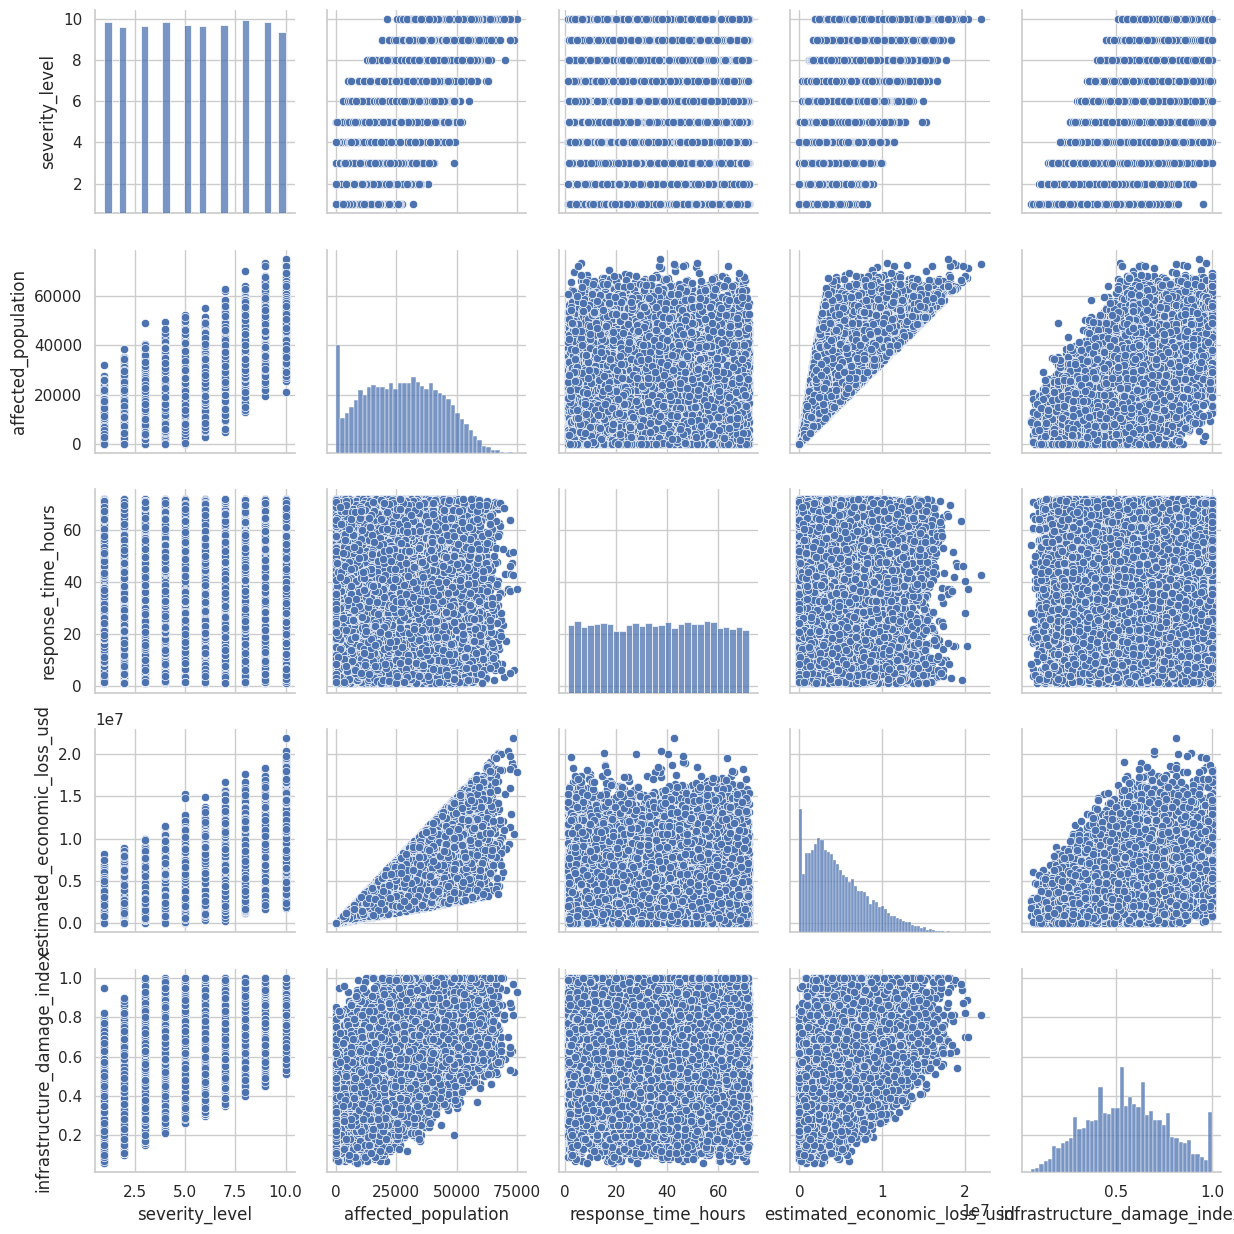

In [ ]:
sns.pairplot(df[['severity_level',
                 'affected_population',
                 'response_time_hours',
                 'estimated_economic_loss_usd',
                 'infrastructure_damage_index']])
plt.tight_layout()
plt.rcParams['axes.labelsize'] = 5
plt.rcParams['axes.labelpad'] = 5
plt.show()

/tmp/ipykernel_3990/2389963999.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='is_major_disaster', y='affected_population', ax=axes[0,0], palette='Set1')
/tmp/ipykernel_3990/2389963999.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='is_major_disaster', y='infrastructure_damage_index', ax=axes[0,1], palette='PRGn')
/tmp/ipykernel_3990/2389963999.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='is_major_disaster', y='estimated_economic_loss_usd', ax=axes[1,0], palette='coolwarm')


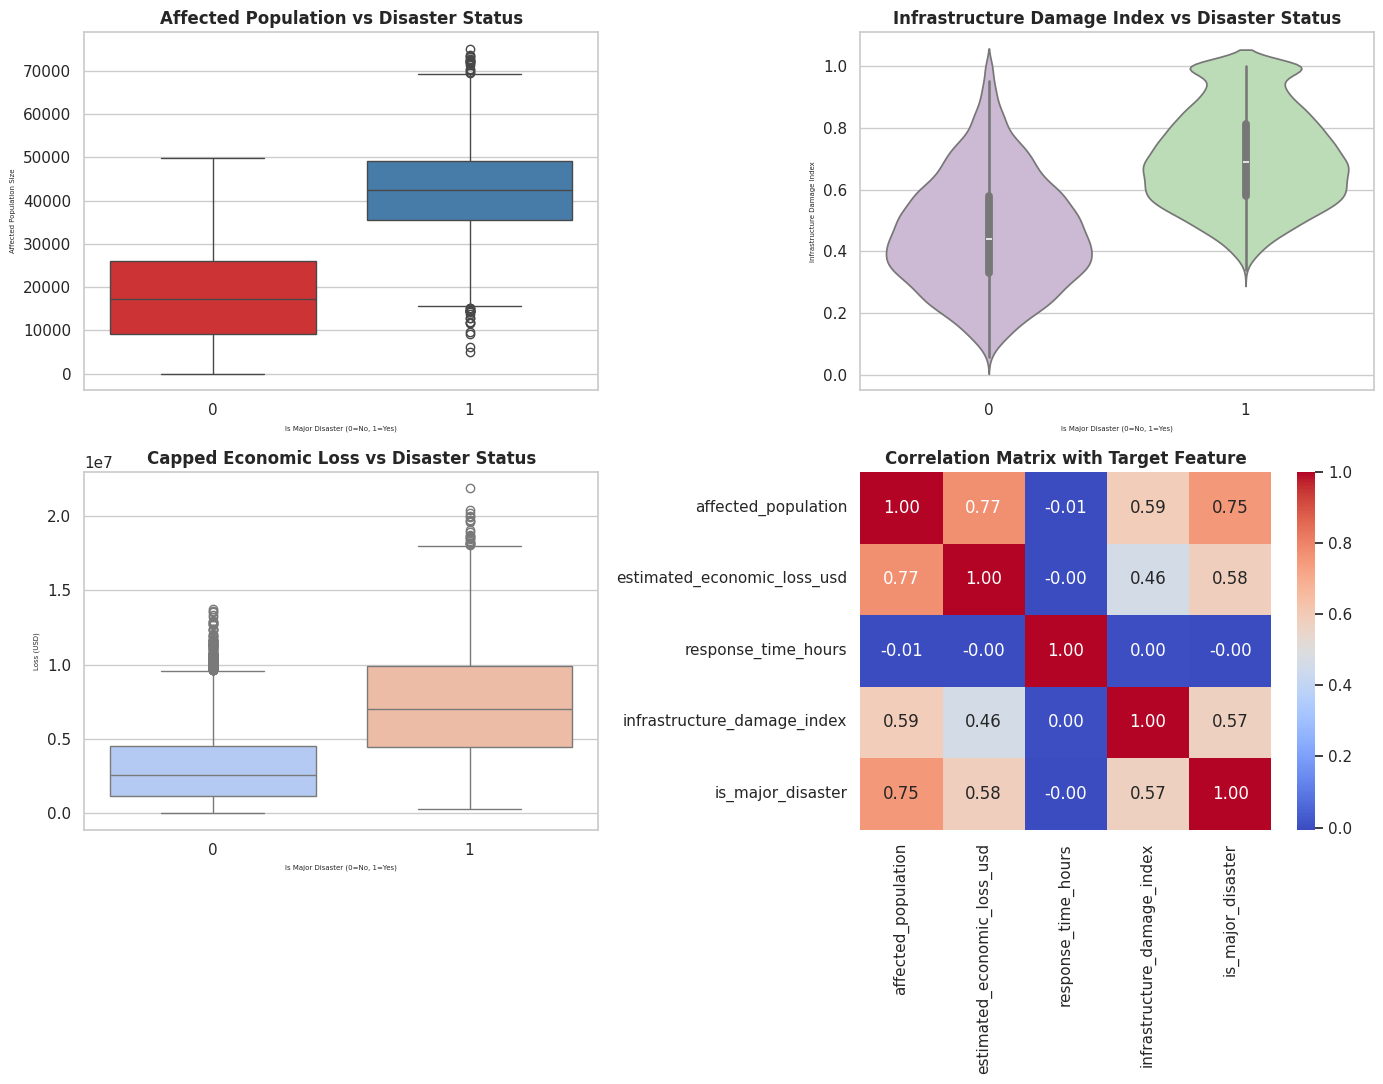

In [ ]:
# Feature vs Target Variables
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
sns.set_theme(style="whitegrid")

# Panel 1: Boxplot for Affected Population
sns.boxplot(data=df, x='is_major_disaster', y='affected_population', ax=axes[0,0], palette='Set1')
axes[0,0].set_title('Affected Population vs Disaster Status', fontsize=12, fontweight='bold')
axes[0,0].set_xlabel('Is Major Disaster (0=No, 1=Yes)')
axes[0,0].set_ylabel('Affected Population Size')

# Panel 2: Violin Plot for Infrastructure Damage Index
sns.violinplot(data=df, x='is_major_disaster', y='infrastructure_damage_index', ax=axes[0,1], palette='PRGn')
axes[0,1].set_title('Infrastructure Damage Index vs Disaster Status', fontsize=12, fontweight='bold')
axes[0,1].set_xlabel('Is Major Disaster (0=No, 1=Yes)')
axes[0,1].set_ylabel('Infrastructure Damage Index')

# Panel 3: Boxplot for Capped Financial Losses
sns.boxplot(data=df, x='is_major_disaster', y='estimated_economic_loss_usd', ax=axes[1,0], palette='coolwarm')
axes[1,0].set_title('Capped Economic Loss vs Disaster Status', fontsize=12, fontweight='bold')
axes[1,0].set_xlabel('Is Major Disaster (0=No, 1=Yes)')
axes[1,0].set_ylabel('Loss (USD)')

# Panel 4: Bivariate Heatmap Matrix
num_cols = ['affected_population', 'estimated_economic_loss_usd', 'response_time_hours', 'infrastructure_damage_index', 'is_major_disaster']
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", ax=axes[1,1], cbar=True)
axes[1,1].set_title('Correlation Matrix with Target Feature', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('bivariate_analysis_report.png', dpi=300)
plt.show()

In [ ]:
# =====================================================================
# Feature Encoding (Categorical → Numerical)
# =====================================================================
# 'disaster_type', 'location', and 'aid_provided' are nominal categories with no hierarchy.
# We apply One-Hot Encoding and use drop_first=True to avoid the multicollinearity trap.
data = pd.DataFrame({
    'Disaster_Type': ['Wildfire', 'Hurricane', 'Flood', 'Wildfire'],
    'Severity_Rank': ['Low', 'High', 'Medium', 'Low']
})

In [ ]:
# 1. Applying ONE-HOT ENCODING (For nominal 'Disaster_Type')
# drop_first=True prevents the Dummy Variable Trap
one_hot_encoded = pd.get_dummies(data, columns=['Disaster_Type'], drop_first=True)

# 2. Applying LABEL ENCODING (For ordinal 'Severity_Rank')
le = LabelEncoder()
data['Severity_Rank_Encoded'] = le.fit_transform(data['Severity_Rank'])

print("--- One-Hot Encoded (Nominal Feature Extracted) ---")
print(one_hot_encoded)

print("\n--- Label Encoded (Ordinal Hierarchy Assigned) ---")
print(data[['Severity_Rank', 'Severity_Rank_Encoded']])

--- One-Hot Encoded (Nominal Feature Extracted) ---
  Severity_Rank  Disaster_Type_Hurricane  Disaster_Type_Wildfire
0           Low                    False                    True
1          High                     True                   False
2        Medium                    False                   False
3           Low                    False                    True

--- Label Encoded (Ordinal Hierarchy Assigned) ---
  Severity_Rank  Severity_Rank_Encoded
0           Low                      1
1          High                      0
2        Medium                      2
3           Low                      1


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# 1. Isolate features and target, then split FIRST
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define continuous columns that require scaling
continuous_features = ['affected_population', 'estimated_economic_loss_usd', 'response_time_hours']

# ==========================================
# OPTION A: STANDARDIZATION (Recommended)
# ==========================================
scaler = StandardScaler()

# Learn mean/std from X_train AND scale X_train
X_train_scaled = X_train.copy()
X_train_scaled[continuous_features] = scaler.fit_transform(X_train[continuous_features])

# DO NOT FIT HERE. Use the exact training mean/std to scale X_test
X_test_scaled = X_test.copy()
X_test_scaled[continuous_features] = scaler.transform(X_test[continuous_features])


# ==========================================
# OPTION B: NORMALIZATION (Alternative)
# ==========================================
normalizer = MinMaxScaler()

# Learn min/max from X_train AND scale X_train
X_train_normalized = X_train.copy()
X_train_normalized[continuous_features] = normalizer.fit_transform(X_train[continuous_features])

# Scale X_test using training boundaries
X_test_normalized = X_test.copy()
X_test_normalized[continuous_features] = normalizer.transform(X_test[continuous_features])

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split





# ==========================================
# VERIFICATION AUDIT
# ==========================================
print("--- Step 8: Train-Test Split Verification ---")
print(f"Total Rows Ingested : {len(df)}")
print(f"Training Data Shapes: Features Matrix {X_train.shape} | Target {y_train.shape}")
print(f"Testing Data Shapes : Features Matrix {X_test.shape}  | Target {y_test.shape}\n")

print("--- Stratification Balance Proportions Check ---")
print("Original Target Balance:")
print(y.value_counts(normalize=True))

print("\nTraining Split Target Balance:")
print(y_train.value_counts(normalize=True))

print("\nTesting Split Target Balance:")
print(y_test.value_counts(normalize=True))
print("\n✔ Stratification confirmed. No class distribution drift detected.")

--- Step 8: Train-Test Split Verification ---
Total Rows Ingested : 20000
Training Data Shapes: Features Matrix (16000, 20) | Target (16000,)
Testing Data Shapes : Features Matrix (4000, 20)  | Target (4000,)

--- Stratification Balance Proportions Check ---
Original Target Balance:
is_major_disaster
0    0.59995
1    0.40005
Name: proportion, dtype: float64

Training Split Target Balance:
is_major_disaster
0    0.597125
1    0.402875
Name: proportion, dtype: float64

Testing Split Target Balance:
is_major_disaster
0    0.61125
1    0.38875
Name: proportion, dtype: float64

✔ Stratification confirmed. No class distribution drift detected.


In [ ]:
# Fast, Interpretable & Baseline Model
from sklearn.linear_model import LogisticRegression
# Easy to Visualize & Non-Linearity x Overfitting issues
from sklearn.tree import DecisionTreeClassifier
# Reduces Overfitting, Strong Baseline x Larger Models
from sklearn.ensemble import RandomForestClassifier
# Excellent Performance & Handles Complex Patterns
from sklearn.ensemble import GradientBoostingClassifier
# Simple Boosting algorithm x Sensitive to the Noisy Data
from sklearn.ensemble import AdaBoostClassifier
# High Accuracy & Handles the Tabular data
from xgboost import XGBClassifier
# Faster than XG & Larger Datasets
from lightgbm import LGBMClassifier
# Handles Categorical Feature & Minimal Processing
from catboost import CatBoostClassifier

lr = LogisticRegression(max_iter=1000)
dt = DecisionTreeClassifier(random_state=42)
rf = RandomForestClassifier(random_state=42)
gb = GradientBoostingClassifier(random_state=42)
ab = AdaBoostClassifier(random_state=42)
xgb = XGBClassifier(random_state=42, eval_metric='logloss')
lgbm = LGBMClassifier(random_state=42)
cb = CatBoostClassifier(
    verbose=0,
    random_state=42
)

In [ ]:
!pip install catboost

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

results = []



In [ ]:
models = {
    "Logistic Regression": lr,
    "Decision Tree": dt,
    "Random Forest": rf,
    "Gradient Boosting": gb,
    "AdaBoost": ab,
    "XGBoost": xgb,
    "LightGBM": lgbm,
    "CatBoost": cb
}

for name, model in models.items():

    model.fit(X_train, y_train)

    preds = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1": f1_score(y_test, preds)
    })



[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 6446, number of negative: 9554
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.008175 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1399
[LightGBM] [Info] Number of data points in the train set: 16000, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.402875 -> initscore=-0.393500
[LightGBM] [Info] Start training from score -0.393500


In [ ]:
results_df = pd.DataFrame(results)

results_df.sort_values(
    by="F1",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1
3,Gradient Boosting,0.89675,0.858218,0.879743,0.868847
7,CatBoost,0.89525,0.858586,0.874598,0.866518
2,Random Forest,0.89350,0.856601,0.872026,0.864245
5,XGBoost,0.89075,0.853797,0.867524,0.860606
4,AdaBoost,0.88975,0.846824,0.874598,0.860487
6,LightGBM,0.88950,0.849780,0.869453,0.859504
0,Logistic Regression,0.87750,0.841127,0.844373,0.842747
1,Decision Tree,0.84700,0.801663,0.805788,0.803720


In [ ]:
df.to_csv("Synthetic_Disaster_Events_Cleaned.csv", index=False)

print("Cleaned dataset saved successfully")

Cleaned dataset saved successfully


In [ ]:
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import numpy as np

# Assuming X_train, X_test, y_train_reg, y_test_reg are ready for Regression
# Assuming X_train, X_test, y_train_clf, y_test_clf are ready for Classification

# --- 1. REGRESSION BASELINE ---
baseline_reg = LinearRegression()
baseline_reg.fit(X_train, y_train)
y_pred_base_reg = baseline_reg.predict(X_test)

# --- 2. CLASSIFICATION BASELINE ---
baseline_clf = LogisticRegression(max_iter=1000, random_state=42)
baseline_clf.fit(X_train, y_train)
y_pred_base_clf = baseline_clf.predict(X_test)

In [ ]:
# Import all required libraries
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingRegressor, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

# Define dictionaries to easily loop through them
regression_models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree Regressor": DecisionTreeRegressor(random_state=42),
    "Random Forest Regressor": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting Regressor": GradientBoostingRegressor(random_state=42)
}

classification_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree Classifier": DecisionTreeClassifier(random_state=42),
    "Random Forest Classifier": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM Classifier": SVC(random_state=42),
    "Naive Bayes": GaussianNB()
}

In [ ]:
reg_table_data = []
# Note: Replace 'y_train_reg' and 'y_test_reg' with your specific regression targets
for name, model in regression_models.items():
    # 1. Train the model
    model.fit(X_train, y_train)

    # 2. Predict on both sets to analyze diagnostics
    train_preds = model.predict(X_train)
    test_preds = model.predict(X_test)

    # 3. Calculate metrics on Test split
    mae = mean_absolute_error(y_test, test_preds)
    rmse = np.sqrt(mean_squared_error(y_test, test_preds))
    r2_test = r2_score(y_test, test_preds)
    r2_train = r2_score(y_train, train_preds) # Required for variance test

    # 4. Automate Overfitting evaluation
    r2_diff = r2_train - r2_test
    if r2_train < 0.40 and r2_test < 0.40:
        overfitting = "No (Underfitting)"
        remarks = f"High bias. Both R² values are low. Lacks model complexity."
    elif r2_diff > 0.12:
        overfitting = "Yes"
        remarks = f"High variance. Memorized training data (Train R²: {r2_train:.2f} vs Test R²: {r2_test:.2f})."
    else:
        overfitting = "No"
        remarks = "Good balance. Generalizes well to test split data."

    # Append structured metrics dictionary
    reg_table_data.append({
        "Model": name,
        "MAE": f"{mae:,.2f}",
        "RMSE": f"{rmse:,.2f}",
        "R² Score": f"{r2_test:.4f}",
        "Overfitting?": overfitting,
        "Remarks": remarks
    })

# Render performance table
print("=== SPRINT 2: REGRESSION PERFORMANCE SUMMARY TABLE ===")
reg_summary_df = pd.DataFrame(reg_table_data)
pd.set_option('display.max_colwidth', None)
display(reg_summary_df)

=== SPRINT 2: REGRESSION PERFORMANCE SUMMARY TABLE ===


,Model,MAE,RMSE,R² Score,Overfitting?,Remarks
0,Linear Regression,0.25,0.31,0.5973,No,Good balance. Generalizes well to test split data.
1,Decision Tree,0.15,0.39,0.3593,Yes,High variance. Memorized training data (Train R²: 1.00 vs Test R²: 0.36).
2,Random Forest,0.15,0.28,0.6679,Yes,High variance. Memorized training data (Train R²: 0.95 vs Test R²: 0.67).
3,Gradient Boosting,0.15,0.27,0.6979,No,Good balance. Generalizes well to test split data.


In [ ]:
# print("\n=== CLASSIFICATION MODEL EVALUATION ===")
# clf_results = {}

# for name, model in classification_models.items():
#     # Train
#     model.fit(X_train, y_train)
#     # Predict
#     preds = model.predict(X_test)

#     # Calculate Metrics
#     acc = accuracy_score(y_test, y_pred)
#     prec = precision_score(y_test, y_pred, zero_division=0)
#     rec = recall_score(y_test, y_pred, zero_division=0)
#     f1 = f1_score(y_test, y_pred, zero_division=0)
#     cm = confusion_matrix(y_test, y_pred)

#     clf_results[name] = {"Accuracy": acc, "Precision": prec, "Recall": rec, "F1-Score": f1}
#     print(f"\n[{name}] Metrics:")
#     print(f"  Accuracy : {acc:.4f}")
#     print(f"  Precision: {prec:.4f}")
#     print(f"  Recall   : {rec:.4f}")
#     print(f"  F1 Score : {f1:.4f}")
#     print(f"  Confusion Matrix:\n{cm}")

clf_table_data = []

# Note: Replace 'y_train_clf' and 'y_test_clf' with your 'is_major_disaster' targets
for name, model in classification_models.items():
    # 1. Train the model
    model.fit(X_train, y_train)

    # 2. Predict both sets
    train_preds = model.predict(X_train)
    test_preds = model.predict(X_test)

    # 3. Calculate all required metrics
    acc_test = accuracy_score(y_test, test_preds)
    acc_train = accuracy_score(y_train, train_preds)
    precision = precision_score(y_test, test_preds, zero_division=0)
    recall = recall_score(y_test, test_preds, zero_division=0)
    f1 = f1_score(y_test, test_preds, zero_division=0)
    cm = confusion_matrix(y_test, test_preds)

    # Flatten confusion matrix array into a readable string [TN, FP, FN, TP]
    cm_str = f"TN:{cm[0][0]} FP:{cm[0][1]} | FN:{cm[1][0]} TP:{cm[1][1]}"

    # 4. Automate classification overfitting calculation
    acc_diff = acc_train - acc_test
    if acc_train > 0.95 and acc_test < 0.80:
        overfitting = "Yes"
        remarks = f"Overfit. Training Accuracy ({acc_train:.2f}) dropped drastically on Test ({acc_test:.2f})."
    elif acc_train < 0.60 and acc_test < 0.60:
        overfitting = "No (Underfitting)"
        remarks = "Model fails to find distinguishing characteristics patterns."
    else:
        overfitting = "No"
        remarks = "Stable model. Consistent predictions across split sets."

    clf_table_data.append({
        "Model": name,
        "Accuracy": f"{acc_test:.4f}",
        "Precision": f"{precision:.4f}",
        "Recall": f"{recall:.4f}",
        "F1 Score": f"{f1:.4f}",
        "Confusion Matrix": cm_str,
        "Overfitting?": overfitting,
        "Remarks": remarks
    })

# Render classification table
print("=== SPRINT 2: CLASSIFICATION PERFORMANCE SUMMARY TABLE ===")
clf_summary_df = pd.DataFrame(clf_table_data)
pd.set_option('display.max_colwidth', None)
display(clf_summary_df)

=== SPRINT 2: CLASSIFICATION PERFORMANCE SUMMARY TABLE ===


,Model,Accuracy,Precision,Recall,F1 Score,Confusion Matrix,Overfitting?,Remarks
0,Logistic Regression,0.8775,0.8411,0.8444,0.8427,TN:2197 FP:248 | FN:242 TP:1313,No,Stable model. Consistent predictions across split sets.
1,Decision Tree Classifier,0.8470,0.8017,0.8058,0.8037,TN:2135 FP:310 | FN:302 TP:1253,No,Stable model. Consistent predictions across split sets.
2,Random Forest Classifier,0.8935,0.8566,0.8720,0.8642,TN:2218 FP:227 | FN:199 TP:1356,No,Stable model. Consistent predictions across split sets.
3,SVM Classifier,0.7590,0.7432,0.5807,0.6520,TN:2133 FP:312 | FN:652 TP:903,No,Stable model. Consistent predictions across split sets.
4,Naive Bayes,0.8658,0.8222,0.8354,0.8287,TN:2164 FP:281 | FN:256 TP:1299,No,Stable model. Consistent predictions across split sets.


In [ ]:

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, roc_auc_score
import joblib

# Load the dataset
# Replace 'synthetic_disaster_events_2025.csv' with your actual local path if different
df = pd.read_csv("synthetic_disaster_events_2025.csv")

# ==========================================
# STEP 1: FEATURE ENGINEERING
# ==========================================
print("--- Step 1: Feature Engineering ---")

# 1. Ratio: Estimated Economic Loss per Affected Person
df['loss_per_capita'] = df['estimated_economic_loss_usd'] / (df['affected_population'] + 1)

# 2. Aggregation: Average economic loss by disaster type (Domain-specific context)
mean_loss_by_type = df.groupby('disaster_type')['estimated_economic_loss_usd'].transform('mean')
df['type_avg_economic_loss'] = mean_loss_by_type

# 3. Domain Transformation: Interaction between severity and infrastructure damage
df['severity_infrastructure_impact'] = df['severity_level'] * df['infrastructure_damage_index']


# ==========================================
# STEP 2: FEATURE SELECTION
# ==========================================
print("--- Step 2: Feature Selection ---")

# Drop completely irrelevant or high-cardinality ID/Date tracking features
features_to_drop = ['event_id', 'date', 'latitude', 'longitude']
df = df.drop(columns=features_to_drop)

# Separate Target and Features
# Assuming 'is_major_disaster' is the target variable based on the dataset schema
X = df.drop(columns=['is_major_disaster'])
y = df['is_major_disaster']

# Handle correlation check strictly on numerical features to prevent multi-collinearity
numerical_cols = X.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = X[numerical_cols].corr().abs()

# Identify features with a correlation higher than 0.85 to drop
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > 0.85)]
print(f"Dropping highly correlated features: {to_drop}")
X = X.drop(columns=to_drop)

# Split into Train and Test sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


# ==========================================
# PREPROCESSING PIPELINE Setup
# ==========================================
cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ])


# ==========================================
# STEP 3: HYPERPARAMETER TUNING
# ==========================================
print("--- Step 3: Hyperparameter Tuning ---")

# Setup pipeline with placeholder estimator
full_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                               ('classifier', RandomForestClassifier(random_state=42))])

# Define hyperparameter search space
param_distributions = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [10, 20, None],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4]
}

# Use RandomizedSearchCV for faster, highly effective exploration
search = RandomizedSearchCV(
    full_pipeline,
    param_distributions,
    n_iter=10,
    cv=3,
    scoring='f1',
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)
print(f"Best Parameters Found: {search.best_params_}")


# ==========================================
# STEP 4: BUILD FINAL MODEL
# ==========================================
print("--- Step 4: Building Final Model ---")
# RandomizedSearchCV automatically fits the best model configuration on the whole training set
final_model = search.best_estimator_


# ==========================================
# STEP 5: FINAL EVALUATION
# ==========================================
print("--- Step 5: Final Evaluation ---")
y_pred = final_model.predict(X_test)
y_proba = final_model.predict_proba(X_test)[:, 1]

print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}\n")


# ==========================================
# STEP 6: MODEL SERIALIZATION
# ==========================================
print("--- Step 6: Model Serialization ---")
model_filename = 'final_disaster_model.joblib'
joblib.dump(final_model, model_filename)
print(f"Success! Final model pipeline saved as: {model_filename}")

--- Step 1: Feature Engineering ---
--- Step 2: Feature Selection ---
Dropping highly correlated features: ['affected_population', 'severity_infrastructure_impact']
--- Step 3: Hyperparameter Tuning ---
Best Parameters Found: {'classifier__n_estimators': 100, 'classifier__min_samples_split': 5, 'classifier__min_samples_leaf': 1, 'classifier__max_depth': 20}
--- Step 4: Building Final Model ---
--- Step 5: Final Evaluation ---

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2400
           1       1.00      1.00      1.00      1600

    accuracy                           1.00      4000
   macro avg       1.00      1.00      1.00      4000
weighted avg       1.00      1.00      1.00      4000

ROC-AUC Score: 1.0000

--- Step 6: Model Serialization ---
Success! Final model pipeline saved as: final_disaster_model.joblib
